Group Names: Andrew Mankin, Ryan 

Delete the .gz after processning of data to know they are finsihed

Negative Dataset parts downloaded: covid19_neg_partab, covid19_neg_partae, covid19_neg_partaf, covid19_neg_partah,covid19_neg_partai

Positive Dataset parts downloaded: bimcv_covid19_posi_subjects_1, bimcv_covid19_posi_subjects_2, bimcv_covid19_posi_subjects_3,bimcv_covid19_posi_subjects_4,bimcv_covid19_posi_subjects_5,bimcv_covid19_posi_subjects_6

In [1]:
import json
import os
import shutil
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as img


In [17]:
IMAGE_DIR = "./dataset/images"
JSON_DIR = "./dataset/metadata"
os.makedirs(JSON_DIR, exist_ok=True)
os.makedirs(IMAGE_DIR, exist_ok=True)
start_dir = "./bimcv_covid19_posi_subjects_6"
for root, dirs, files in os.walk(start_dir):
    for filename in files:
        if filename.endswith(".png"):
            new_img_path = os.path.join(IMAGE_DIR, filename)
            new_json_path = os.path.join(JSON_DIR, filename.replace(".png", ".json"))

            img_path = os.path.join(root, filename)
            json_path = os.path.join(root, filename.replace(".png",".json"))

            if os.path.exists(img_path):
                shutil.copy(img_path, new_img_path)
            if os.path.exists(json_path):
                shutil.copy(json_path, new_json_path)

In [18]:
rows = []
for root,dirs, files in os.walk("./dataset/metadata"):
    for file in files:
        img_file = file.replace(".json",".png")
        json_path = os.path.join(root,file)
        with open(json_path) as file:
            data = json.load(file)

        result = data['00104000']['Value'][0]
        # 1: positive 0: negative
        if result.split()[0].split(":")[1] == "covid19_posi":
            covid_result = 1
        else:
            covid_result = 0
        imageType = data["00280004"]['Value'][0]
#os.path.join("./dataset/images",image_test)
        image = os.path.join("./dataset/images",img_file)
        
        rows.append((image, imageType, covid_result))
df = pd.DataFrame(rows,columns=["image", "photometric","label"])

In [19]:
df.to_csv("./dataset/labels.csv",index=False)

In [20]:
df.loc[df["label"]==0]

,image,photometric,label
1,./dataset/images/sub-S28417_ses-E60904_run-2_b...,MONOCHROME2,0
6,./dataset/images/sub-S06780_ses-E12064_run-2_b...,MONOCHROME2,0
7,./dataset/images/sub-S24998_ses-E51784_run-1_b...,MONOCHROME1,0
9,./dataset/images/sub-S05073_ses-E10217_run-1_b...,MONOCHROME2,0
14,./dataset/images/sub-S25530_ses-E52794_run-1_b...,MONOCHROME2,0
...,...,...,...
1234,./dataset/images/sub-S05633_ses-E11944_run-1_b...,MONOCHROME1,0
1246,./dataset/images/sub-S23946_ses-E52770_run-1_b...,MONOCHROME2,0
1248,./dataset/images/sub-S06835_ses-E12144_run-1_b...,MONOCHROME2,0
1252,./dataset/images/sub-S08032_ses-E14275_run-1_b...,MONOCHROME2,0


In [21]:
df

,image,photometric,label
0,./dataset/images/sub-S03224_ses-E08049_run-1_b...,MONOCHROME1,1
1,./dataset/images/sub-S28417_ses-E60904_run-2_b...,MONOCHROME2,0
2,./dataset/images/sub-S03071_ses-E06165_run-1_b...,MONOCHROME2,1
3,./dataset/images/sub-S03113_ses-E07104_run-1_b...,MONOCHROME1,1
4,./dataset/images/sub-S03119_ses-E06213_run-1_b...,MONOCHROME2,1
...,...,...,...
1252,./dataset/images/sub-S08032_ses-E14275_run-1_b...,MONOCHROME2,0
1253,./dataset/images/sub-S03106_ses-E06431_acq-2_r...,MONOCHROME2,1
1254,./dataset/images/sub-S03056_ses-E07055_run-1_b...,MONOCHROME2,1
1255,./dataset/images/sub-S05731_ses-E10513_run-1_b...,MONOCHROME2,0


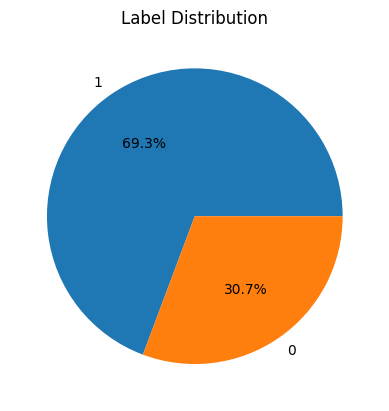

In [22]:
counts = df["label"].value_counts()

plt.pie(counts, labels=counts.index, autopct='%1.1f%%')
plt.title("Label Distribution")
plt.show()